# Description
Calculation of the number of passes using real breadcrumbs. Finished on May 18th, 2026. It is the first version it can count by boundary cell. The grid is done by rectangles

In [1]:
%load_ext autoreload
%autoreload 2
%reset -f
%matplotlib widget

In [2]:
from locallib.picarrodb import *
from locallib.query import *
from locallib.box import *
from locallib.query import *

from NOP import *

import matplotlib.pyplot as plt
from shapely import wkt


EU1_Conn created successfully
EU2_Conn created successfully
DataHub_Conn created successfully
US_Conn created successfully


/home/sandbox/personal-repos/MutiplePassDetection/OSM/r3/NOP.py:17: UserWarning: registration of accessor <class 'NOP.NOPAccessor'> under name 'nop' for type <class 'pandas.core.frame.DataFrame'> is overriding a preexisting attribute with the same name.
  @pd.api.extensions.register_dataframe_accessor("nop")


# Configuration

# Query the surveys

In [3]:
a = get_reports('Cadent',years = [2026]).execute([EU2_Conn])
report_bc = a.iloc[[700]].copy()
#report_bc.to_csv('Reports_used.csv', mode='a', header=False, index=False)
report_bc.db.set_query(query_Segments_byReport(report_table = '#TempReport'))
segments = report_bc.db.execute([EU2_Conn], source_col = 'ReportId', temp_table_name = '#TempReport')
# Create a GeoDataFrame for the segments with geometry from the Breadcrumb column
segments['geometry'] = segments['Breadcrumb'].apply(wkt.loads)
segments_gdf = gpd.GeoDataFrame(segments, geometry='geometry', crs='EPSG:4326')


In [4]:
# Get the unique SurveyIds from the segments DataFrame
survey_ids = pd.DataFrame(segments['SurveyId'].unique(), columns=['SurveyId'])
survey_ids.db.set_query(f"SELECT SA.SurveyId, Shape.STAsText() as SurveyAreaBoundary FROM SurveyArea SA WHERE SA.SurveyId IN (SELECT SurveyId FROM #TempSurveys)")
s = survey_ids.db.execute(EU2_Conn, source_col = 'SurveyId', temp_table_name = '#TempSurveys')

# Extract all the streets needed (Pre driving)

/tmp/ipykernel_68494/2426088613.py:6: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  segments_union = segments_gdf.unary_union


<Axes: >

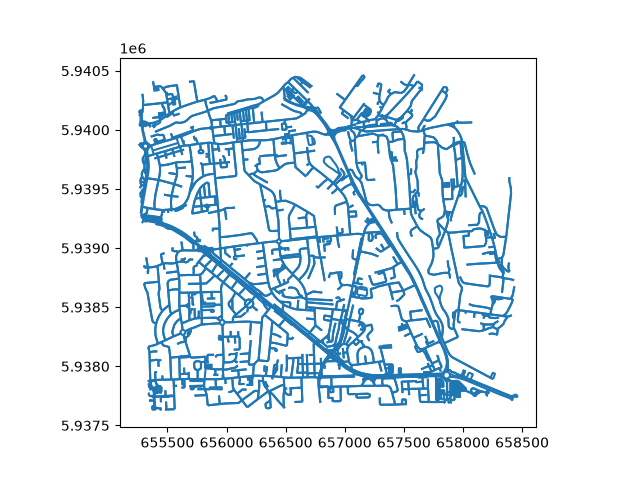

In [5]:
import osmnx as ox
from shapely.geometry import box

# From all segments, make a union and extract the bounds

segments_union = segments_gdf.unary_union
segments_union_bounds = segments_union.bounds if hasattr(segments_union, "bounds") else None
bbox_poly = box(*segments_union_bounds)

# Download only edges that are (at least partially) within bbox
# This will NOT download the full network, only roads partly or fully within the bbox
G = ox.graph_from_polygon(bbox_poly, network_type="all", retain_all=False)

# Convert to GeoDataFrame
nodes, edges = ox.graph_to_gdfs(G)
edges = edges.set_crs("EPSG:4326", allow_override=True)

# Crop each road geometry to the bounding box (keep only cropped part inside bbox)
edges['geometry'] = edges['geometry'].intersection(bbox_poly)
edges = edges[~edges.is_empty]
utm_crs = edges.estimate_utm_crs()
edges = edges.to_crs(utm_crs)
edges.set_geometry('geometry', inplace=True)
edges.plot()

In [6]:
edges.nop.prepare_survey_gdf()
road_grid = edges.nop.generate_grid()
net = edges.nop.create_network()

Center of the bounds: POINT (656858.23297 5939048.39436)
Processing angle:  0
Processing angle:  -10.0
Processing angle:  -20.0
Processing angle:  -30.0
Processing angle:  -40.0
Processing angle:  -50.0
Processing angle:  -60.0
Processing angle:  -70.0
Processing angle:  -80.0
Processing angle:  -90.0
Processing angle:  -100.0
Processing angle:  -110.0
Processing angle:  -120.0
Processing angle:  -130.0
Processing angle:  -140.0
Processing angle:  -150.0
Processing angle:  -160.0
Processing angle:  -170.0
Processing angle:  -180.0
Total boundaries: 15768
Boundaries with no NaN 'nop': 15541
Boundaries after length and spread filters: 14365
Boundaries after removing overlaps: 10794
Boundaries after removing close together cells: 9808
9808 splitters -> 9273 cells
Created network with 9273 nodes and 9768 edges.


In [31]:
road_grid

,cell_idx,geometry
0,0,"POLYGON ((655255.761 5940146.939, 655255.418 5..."
1,1,"POLYGON ((655255.568 5940153.961, 655260.928 5..."
2,2,"POLYGON ((655281.712 5940168.413, 655287.932 5..."
3,3,"POLYGON ((655288.385 5940173.901, 655289.275 5..."
4,4,"POLYGON ((655289.275 5940183.908, 655289.472 5..."
...,...,...
9268,9268,"POLYGON ((658417.338 5938605.775, 658419.745 5..."
9269,9269,"POLYGON ((658419.745 5938615.515, 658421.64 59..."
9270,9270,"POLYGON ((658423.68 5938635.149, 658425.25 593..."
9271,9271,"POLYGON ((658428.996 5938664.704, 658429.538 5..."


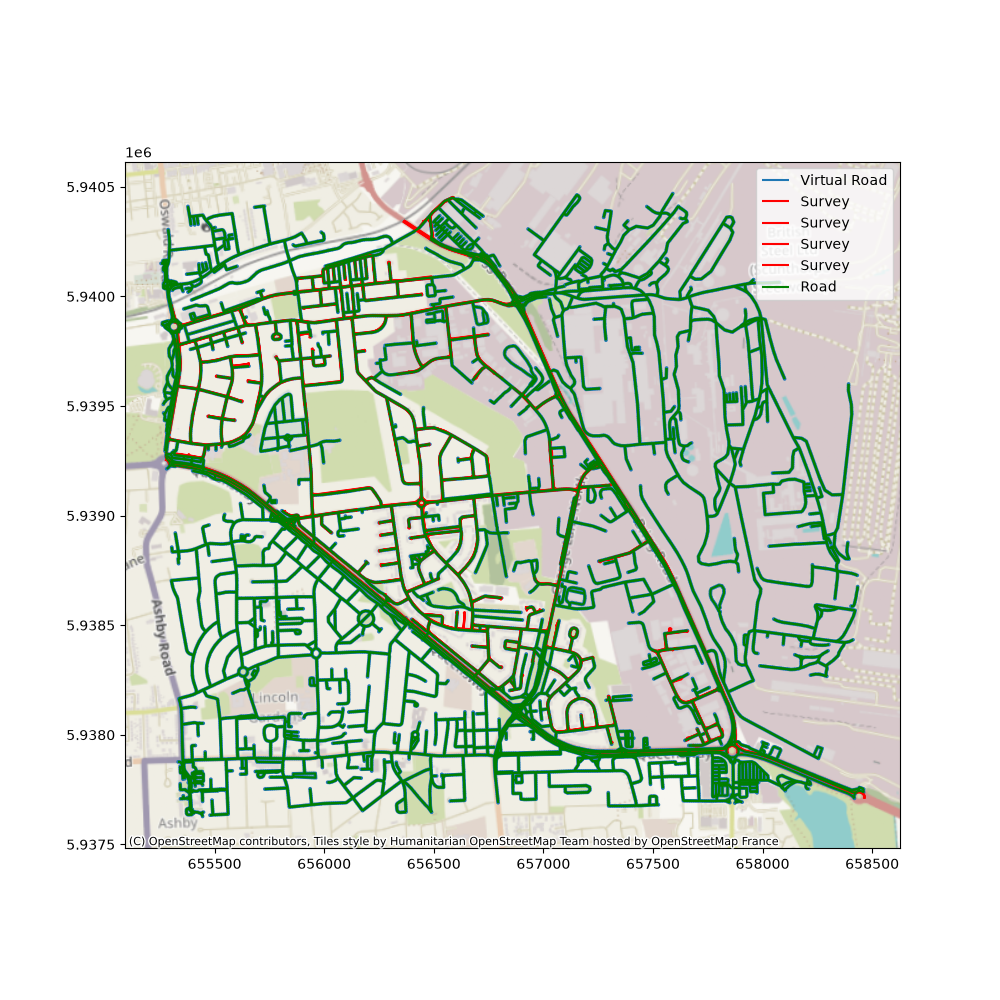

In [33]:
import contextily as ctx

ax = road_grid.boundary.plot(label='Virtual Road', figsize=(10, 10))
for s in surveys:
    s.plot(ax=ax, color='red', label='Survey')
edges.plot(ax=ax, color='green', label='Road')
ax.legend()

# Add basemap from contextily, adjust crs to Web Mercator if not already
if ax.collections:
    try:
        ctx.add_basemap(ax, crs=edges.crs)
    except Exception:
        # fallback: reproject to web mercator if needed
        edges_webm = edges.to_crs(epsg=3857)
        ax = edges_webm.plot(ax=ax, color='green', label='Road')
        ctx.add_basemap(ax, crs=edges_webm.crs)

In [7]:
# Get the segments for each survey (as a list of DataFrames)
segments_per_survey = [df for _, df in segments.groupby('SurveyId')]
output = []
surveys = []
for i in range(len(segments_per_survey)):
    survey_gdf = segments_per_survey[i].copy()
    survey_gdf['geometry'] = survey_gdf['Breadcrumb'].apply(wkt.loads)
    survey_gdf = gpd.GeoDataFrame(survey_gdf, geometry='geometry', crs='EPSG:4326')
    utm_crs = survey_gdf.estimate_utm_crs()
    survey_gdf = survey_gdf.to_crs(utm_crs)
    survey_gdf.set_geometry('geometry', inplace=True)
    surveys.append(survey_gdf)

In [8]:
all_covers = []
for survey in surveys:
    cover = gpd.overlay(survey, road_grid, how='intersection')
    cover['cell_road_length'] = cover.geometry.length
    cover_agg = cover.groupby('cell_idx').agg({'cell_road_length': 'sum'}).reset_index()
    all_covers.append(cover_agg)

# Concatenate all into one GeoDataFrame, summing in case of overlaps
all_covers_gdf = pd.concat(all_covers).groupby('cell_idx', as_index=False).agg({ 'cell_road_length': 'sum'})
all_covers_gdf


,cell_idx,cell_road_length
0,169,26.087836
1,170,18.915940
2,172,18.797763
3,173,14.444460
4,174,30.004729
...,...,...
2561,9248,6.865621
2562,9253,22.452851
2563,9254,49.057291
2564,9255,20.067970


In [9]:
# Create a unique index on edges DataFrame
edges_s = edges.reset_index(drop=True)
edges.index.name = 'edge_idx'

edges_segmented = gpd.overlay(edges_s, road_grid, how='intersection')
edges_segmented['cell_road_length'] = edges_segmented.geometry.length

In [10]:
single_road = edges_segmented[['cell_idx', 'cell_road_length']]

In [11]:
nop = all_covers_gdf/single_road

In [12]:
cell_wnop

NameError: name 'cell_wnop' is not defined

In [ ]:
cell_wnop = pd.merge(road_grid, nop, on='cell_idx', how='left')
cell_wnop.plot(column = 'cell_road_length', cmap = 'Set1', figsize = (10,10), legend = True)
